# Customer Churn Modelling

Pada tahap ini dilakukan pembangunan model machine learning untuk memprediksi kemungkinan pelanggan melakukan churn. Model prediksi churn bertujuan untuk mengidentifikasi pelanggan yang berpotensi berhenti menggunakan layanan sehingga perusahaan dapat melakukan tindakan retensi secara lebih proaktif.

Dataset yang digunakan pada tahap ini merupakan hasil dari proses **data preparation dan feature engineering** pada tahap sebelumnya. Dataset tersebut telah disimpan dalam database sebagai **`churn_feature_dataset`**, yang berisi berbagai fitur pelanggan seperti karakteristik layanan, perilaku penggunaan, serta informasi kontrak.

Tahapan utama dalam proses modelling meliputi:

1. **Data Loading dari Database**
   Dataset fitur pelanggan diambil langsung dari database menggunakan koneksi SQL untuk memastikan pipeline analitik tetap terintegrasi dengan sistem penyimpanan data.

2. **Data Preparation untuk Machine Learning**

   * Pemisahan antara **fitur (X)** dan **target variabel (y)**.
   * Identifikasi fitur **numerik** dan **kategorikal** untuk keperluan preprocessing.

3. **Preprocessing Pipeline**
   Proses preprocessing dilakukan menggunakan **Scikit-Learn Pipeline** untuk memastikan seluruh transformasi data dilakukan secara konsisten. Tahapan ini meliputi:

   * Imputasi missing value pada fitur numerik menggunakan median
   * Imputasi missing value pada fitur kategorikal menggunakan nilai yang paling sering muncul
   * Encoding variabel kategorikal menggunakan **One-Hot Encoding**

4. **Handling Class Imbalance**
   Karena jumlah pelanggan churn lebih sedikit dibandingkan pelanggan yang bertahan, dilakukan beberapa pendekatan untuk menangani **ketidakseimbangan kelas**, yaitu:

   * **Baseline model** tanpa penanganan imbalance
   * **Class weighting**
   * **SMOTE (Synthetic Minority Over-sampling Technique)**

5. **Model Training dan Comparison**
   Beberapa algoritma machine learning digunakan untuk memprediksi churn pelanggan, yaitu:

   * Logistic Regression
   * Random Forest
   * XGBoost

   Setiap model dievaluasi menggunakan beberapa metrik klasifikasi seperti:

   * ROC-AUC
   * PR-AUC
   * Recall
   * F1 Score

6. **Threshold Optimization**
   Selain menggunakan probabilitas prediksi, model juga dioptimalkan dengan mencari **threshold klasifikasi terbaik** berdasarkan **F1-score** dari kurva precision-recall.

7. **Business-Oriented Evaluation**
   Untuk memastikan model yang dipilih memberikan dampak bisnis yang optimal, dilakukan evaluasi tambahan menggunakan metrik **Expected Business Loss**, yaitu estimasi kerugian yang mungkin terjadi jika pelanggan dengan probabilitas churn tinggi tidak berhasil dipertahankan.

Model dengan **Expected Loss terendah** dipilih sebagai model terbaik untuk digunakan pada tahap scoring pelanggan.

8. **Customer Risk Scoring**
   Model terbaik kemudian digunakan untuk menghitung:

   * **Churn Probability**
   * **Predicted Churn**
   * **Customer Risk Level**
   * **Expected Financial Loss**

Hasil akhir dari proses ini adalah dataset **`churn_risk_score`** yang berisi skor risiko churn untuk setiap pelanggan. Dataset ini disimpan kembali ke database dan dapat digunakan untuk mendukung strategi **customer retention dan churn prevention**.

In [1]:
# ================== Import Libraries ==================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    recall_score,
    f1_score
)

import sys, os
sys.path.append(os.path.abspath(".."))
from scr.database import get_engine

In [2]:
# ================== Load Data ====================

engine = get_engine()

query = "SELECT * FROM churn_feature_dataset;"
df = pd.read_sql(query, engine)

customer_ids = df["customer_id"]

df_model = df.drop(columns=[
    "customer_id",
    "revenue_at_risk",
    "tenure_bucket",
    "spending_segment",
])

In [3]:
# =================== Feature / Target ===================

X = df_model.drop("churn", axis=1)
y = df_model["churn"]

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_22408\3682899023.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [4]:
# ================== Train Test Split ===================

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
# ================== Preprocessing Pipeline ===================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [6]:
# ============== Class Imbalance Parameter =================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [7]:
# =================== Model Definition ===================

def build_pipeline(model, use_smote=False):

    if use_smote:
        return ImbPipeline([
            ("prep", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ])

    return Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])


models = {

    "Baseline Logistic":
        build_pipeline(
            LogisticRegression(max_iter=1000, random_state=42)
        ),

    "Baseline RF":
        build_pipeline(
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                random_state=42
            )
        ),

    "Baseline XGB":
        build_pipeline(
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            )
        ),

    "Weighted Logistic":
        build_pipeline(
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        ),

    "Weighted RF":
        build_pipeline(
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                class_weight="balanced",
                random_state=42
            )
        ),

    "Weighted XGB":
        build_pipeline(
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42
            )
        ),

    "SMOTE Logistic":
        build_pipeline(
            LogisticRegression(max_iter=1000, random_state=42),
            use_smote=True
        ),

    "SMOTE RF":
        build_pipeline(
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                random_state=42
            ),
            use_smote=True
        ),

    "SMOTE XGB":
        build_pipeline(
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                eval_metric="logloss",
                random_state=42
            ),
            use_smote=True
        )
}

In [8]:
# ================ Threshold Optimization =================

def find_best_threshold(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx]


In [9]:
# ================ Evaluation Function =================

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:,1]
    threshold = find_best_threshold(y_test, y_proba)
    y_pred = (y_proba >= threshold).astype(int)
    roc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    temp = pd.DataFrame({
        "customer_id": id_test.values,
        "proba": y_proba
    })

    temp = temp.merge(
        df[["customer_id","monthly_charges"]],
        on="customer_id",
        how="left"
    )

    temp["expected_loss"] = (
        temp["monthly_charges"] * 12 * temp["proba"]
    )

    expected_loss = temp["expected_loss"].sum()

    return {
        "Model": name,
        "ROC_AUC": roc,
        "PR_AUC": pr_auc,
        "Recall": recall,
        "F1": f1,
        "Threshold": threshold,
        "Expected_Loss": expected_loss
    }

In [10]:
# ================ Train and Compare Models =================

results = []

for name, model in models.items():
    print(f"Training {name}...")
    metrics = evaluate_model(name, model)
    results.append(metrics)

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("Expected_Loss")

print("\n🏆 MODEL RANKING")
display(comparison_df)

Training Baseline Logistic...


d:\Data_analyst\telco_churn_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Baseline RF...
Training Baseline XGB...
Training Weighted Logistic...


d:\Data_analyst\telco_churn_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Weighted RF...
Training Weighted XGB...
Training SMOTE Logistic...


d:\Data_analyst\telco_churn_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training SMOTE RF...
Training SMOTE XGB...

🏆 MODEL RANKING


,Model,ROC_AUC,PR_AUC,Recall,F1,Threshold,Expected_Loss
1,Baseline RF,0.843781,0.655476,0.826203,0.630612,0.271472,326206.981018
2,Baseline XGB,0.830954,0.624954,0.767380,0.622560,0.270943,327107.154767
0,Baseline Logistic,0.835286,0.624113,0.818182,0.624490,0.268988,337139.400917
8,SMOTE XGB,0.833490,0.636471,0.783422,0.626738,0.288516,342160.362681
7,SMOTE RF,0.828996,0.614358,0.786096,0.622222,0.376209,392999.531235
5,Weighted XGB,0.833926,0.642260,0.772727,0.637266,0.499854,453995.706684
4,Weighted RF,0.840828,0.645886,0.810160,0.636555,0.472446,469805.197694
6,SMOTE Logistic,0.833444,0.615970,0.836898,0.619802,0.468839,514791.928104
3,Weighted Logistic,0.834449,0.621505,0.823529,0.622851,0.497303,515153.808548


**Model Selection & Performance Insight**

Beberapa model machine learning diuji untuk memprediksi churn pelanggan, yaitu Logistic Regression, Random Forest, dan XGBoost, dengan tiga pendekatan penanganan data tidak seimbang: Baseline, Class Weighting, dan SMOTE.

Berdasarkan hasil evaluasi, model dengan performa terbaik adalah Baseline Random Forest.

Key results:

* Best Model: Random Forest (Baseline)
* ROC-AUC: 0.844
* PR-AUC: 0.655
* Recall: 0.826
* Optimal Threshold: 0.271
* Lowest Expected Business Loss: 326,206

Pemilihan model didasarkan pada Expected Loss, yaitu estimasi kerugian bisnis yang muncul jika perusahaan gagal mempertahankan pelanggan yang berpotensi churn.

Walaupun beberapa model memiliki metrik klasifikasi yang mirip, Random Forest Baseline menghasilkan expected loss paling rendah, sehingga menjadi model yang paling optimal dari sudut pandang bisnis.

In [11]:
# ==================== Select Best Model ====================

best_row = comparison_df.iloc[0]
best_model_name = best_row["Model"]
best_threshold = best_row["Threshold"]
best_model = models[best_model_name]

print("\n Using best model:", best_model_name)
print(" Using best threshold:", round(best_threshold, 4))


 Using best model: Baseline RF
 Using best threshold: 0.2715


In [12]:
# ======== Get Feature Names After Preprocessing ========

preprocessor = best_model.named_steps["prep"]
feature_names = preprocessor.get_feature_names_out()

model = best_model.named_steps["model"]
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    "importance",
    ascending=False
)

print("\n Top Important Features")
display(feature_importance_df.head(20))


 Top Important Features


,feature,importance
4,num__monthly_charges,0.163181
12,cat__contract_name_month-to-month,0.135379
3,num__tenure,0.133426
8,num__contract_risk_flag,0.125107
9,num__clv,0.095240
5,num__total_charges,0.092032
17,cat__payment_name_electronic check,0.073813
14,cat__contract_name_two year,0.037914
7,num__service_count,0.030984
6,num__paperless_billing,0.030556


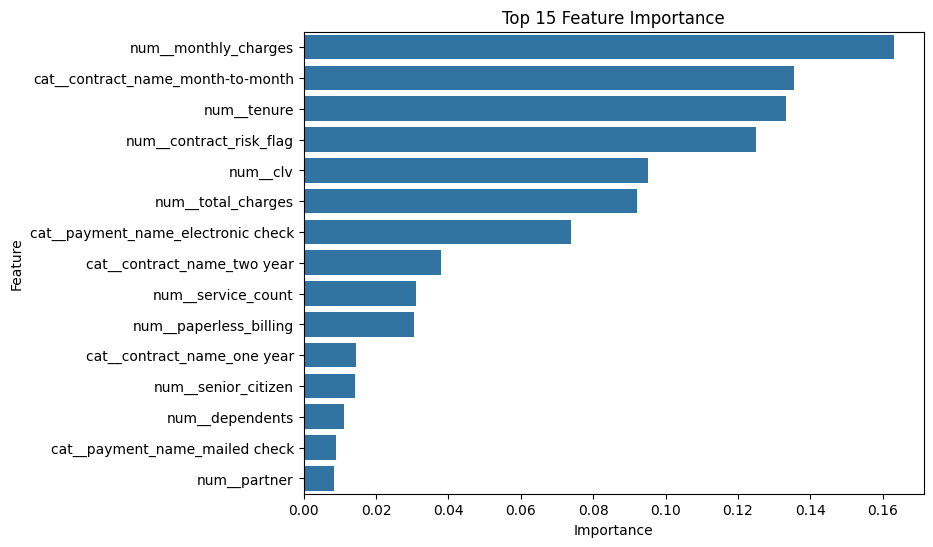

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 15

plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance_df.head(top_n),
    x="importance",
    y="feature"
)

plt.title(f"Top {top_n} Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Feature Importance Insights**

Model menunjukkan bahwa churn pelanggan lebih dipengaruhi oleh faktor finansial dan kontrak dibandingkan karakteristik demografis.

1. Pricing Sensitivity

Monthly Charges merupakan fitur paling berpengaruh dalam model. Ini menunjukkan bahwa kenaikan biaya bulanan berhubungan kuat dengan risiko churn. Total Charges juga berkontribusi besar, mengindikasikan bahwa akumulasi biaya layanan dapat memengaruhi keputusan pelanggan untuk berhenti.

2. Contract Flexibility

Month-to-Month Contract menjadi salah satu prediktor churn terkuat. Pelanggan dengan kontrak bulanan memiliki barrier to exit yang rendah, sehingga lebih mudah untuk berhenti berlangganan dibanding pelanggan dengan kontrak 1–2 tahun.

3. Customer Lifecycle

Tenure memiliki pengaruh tinggi terhadap churn. Pelanggan dengan masa berlangganan lebih lama cenderung lebih loyal, sedangkan pelanggan baru memiliki risiko churn lebih tinggi.

4. Payment Behavior

Metode pembayaran Electronic Check memiliki importance yang cukup tinggi. Hal ini mengindikasikan bahwa pelanggan dengan metode pembayaran non-otomatis mungkin memiliki engagement yang lebih rendah dibanding pelanggan dengan automatic payment.

5. Demographic Factors

Variabel seperti gender, partner, dependents, dan senior citizen memiliki kontribusi yang relatif kecil dalam prediksi churn. Ini menunjukkan bahwa churn lebih dipengaruhi oleh pengalaman layanan dan struktur kontrak dibandingkan profil demografis pelanggan.

In [14]:
# ================= Score All Customers =================

print("\n Scoring all customers using best model...")

churn_probability = best_model.predict_proba(X)[:,1]

df_risk = pd.DataFrame({
    "customer_id": customer_ids.values,
    "churn_probability": churn_probability
})

# predicted churn using optimized threshold
df_risk["predicted_churn"] = (
    df_risk["churn_probability"] >= best_threshold
).astype(int)


 Scoring all customers using best model...


In [15]:
# ================= Risk Segmentation =================

df_risk["risk_level"] = pd.cut(
    df_risk["churn_probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"],
)

In [16]:
# ================ Merge Revenue Data ================

df_risk = df_risk.merge(
    df[["customer_id", "monthly_charges"]],
    on="customer_id",
    how="left"
)

In [17]:
# ============= Calculate Expected Loss ==============

df_risk["expected_loss"] = (
    df_risk["monthly_charges"] * 12 * df_risk["churn_probability"]
)

In [18]:
# ============== Final Output Dataset ===============

df_final = df_risk[[
    "customer_id",
    "churn_probability",
    "risk_level",
    "expected_loss"
]]

print("\nFinal dataset preview:")
display(df_final.head())

print("\nDataset shape:", df_final.shape)


Final dataset preview:


,customer_id,churn_probability,risk_level,expected_loss
0,7590-vhveg,0.567375,Medium,203.233604
1,5575-gnvde,0.055930,Low,38.222550
2,3668-qpybk,0.510529,Medium,329.903944
3,7795-cfocw,0.043752,Low,22.208656
4,9237-hqitu,0.621095,High,526.936802



Dataset shape: (7043, 4)


**Segmentasi Risiko Pelanggan**

Berdasarkan probabilitas churn yang dihasilkan model, pelanggan kemudian dikelompokkan menjadi tiga kategori risiko:

* Low Risk
* Medium Risk
* High Risk

Setiap pelanggan memiliki informasi berikut:
* Churn Probability
* Risk Level
* Expected Financial Loss

Segmentasi ini memungkinkan perusahaan untuk memprioritaskan strategi retensi kepada pelanggan dengan potensi kerugian terbesar.

In [19]:
# ============== Save to Database ===============

from sqlalchemy import text

# hapus data lama
with engine.connect() as conn:
    conn.execute(text("TRUNCATE TABLE churn_risk_score"))
    conn.commit()

# insert data baru
df_final.to_sql(
    "churn_risk_score",
    engine,
    if_exists="append",
    index=False
)

print("Table churn_risk_score updated")

Table churn_risk_score updated
